In [1]:
!pip install timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-10.3.9.90:
      Successfully uninstalled nvidia-curand-cu12-10.3.9.90
  Attemptin

In [2]:
import os
import numpy as np
import torch
import random
from glob import glob
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import timm  # for pretrained ViT models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import f1_score, confusion_matrix


In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [4]:
class AlzheimerDataset(Dataset):
    def __init__(self, root, data_type, transform=None):
        self.transform = transform
        self.image_paths = glob(f"{root}/{data_type}/*/*")
        self.classes = sorted({os.path.basename(os.path.dirname(p)) for p in self.image_paths})
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[os.path.basename(os.path.dirname(img_path))]
        if self.transform:
            image = self.transform(image)
        return image, label


In [5]:
root = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Load full dataset
train_dataset = AlzheimerDataset(root=root, data_type="train", transform=transform)
train_len = int(0.8 * len(train_dataset))
val_len = len(train_dataset) - train_len
train_ds, val_ds = random_split(train_dataset, [train_len, val_len])

# Load test dataset
test_dataset = AlzheimerDataset(root=root, data_type="test", transform=transform)



train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

classes = train_dataset.classes
num_classes = len(classes)
print(f"Total test samples: {len(test_dataset)}")


Total test samples: 1279


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import timm
import os
import numpy as np
from torchvision import transforms

# === Setup ===
model_name = "swin_base_patch4_window7_224"
save_prefix = "mri_swin_finetuned"
save_dir = "saved_models"
device = "cuda" if torch.cuda.is_available() else "cpu"

# === Data Augmentation & Normalization ===
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),                      # Slightly larger resize before crop
    transforms.RandomCrop((224, 224), padding=4),       # Helps with spatial robustness
    transforms.RandomHorizontalFlip(p=0.5),             # Mirror image
    transforms.RandomVerticalFlip(p=0.2),               # Less frequent than horizontal flip
    transforms.RandomRotation(degrees=15),              # Minor orientation shifts
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Simulate lighting variations
    transforms.RandomGrayscale(p=0.1),                  # Reduce color reliance
    transforms.RandAugment(num_ops=2, magnitude=9),     # Add two random ops (robust)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# === Extract labels from original dataset ===
train_labels = []
for i in train_ds.indices:
    _, label = train_dataset[i]
    train_labels.append(label)
num_classes = len(np.unique(train_labels))

# === Define Custom Swin Head ===
class SwinHead(nn.Module):
    def __init__(self, input_features, num_classes):
        super().__init__()
        self.norm = nn.LayerNorm(input_features)
        self.dropout1 = nn.Dropout(0.3)
        self.fc1 = nn.Linear(input_features, 256)
        self.dropout2 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        if x.dim() == 4:
            x = x.permute(0, 3, 1, 2)
            x = F.adaptive_avg_pool2d(x, 1)
            x = x.flatten(1)
        elif x.dim() == 3:
            x = x.mean(dim=1)
        
        x = self.norm(x)
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

# === Create Swin Transformer Model ===
def create_swin_transformer_model(num_classes):
    """Create Swin Transformer model with custom head"""
    model = timm.create_model(model_name, pretrained=True, num_classes=0)
    
    # Get the number of features from the model
    # For Swin transformers, this is typically available as num_features
    if hasattr(model, 'num_features'):
        input_features = model.num_features
    else:
        # Fallback: run a dummy forward pass to get feature size
        dummy_input = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            dummy_output = model(dummy_input)
            input_features = dummy_output.shape[-1]
    
    # Attach custom head
    model.head = SwinHead(input_features, num_classes)
    
    return model

# === Initialize Swin Transformer ===
model = create_swin_transformer_model(num_classes)

# === Fine-tuning Strategy ===
# Option 1: Unfreeze all layers (full fine-tuning)
for param in model.parameters():
    param.requires_grad = True

# Option 2: Progressive unfreezing (uncomment if you prefer gradual unfreezing)
# # First freeze backbone
# for name, param in model.named_parameters():
#     if 'head' not in name:
#         param.requires_grad = False
# # Only head is trainable initially

# === Ensure normalization layers are trainable ===
for name, param in model.named_parameters():
    if "norm" in name:
        param.requires_grad = True

model = model.to(device)

# === Compute class weights from training labels ===
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# === Loss Function: CrossEntropy with Label Smoothing ===
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)

# === Optimizer ===
# Lower learning rate for Swin Transformer
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

# === Scheduler: ReduceLROnPlateau ===
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)

# === Alternative Schedulers (uncomment if preferred) ===
# # Cosine Annealing
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
# 
# # Cosine with Warm Restarts
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

print(f"Swin Transformer model initialized with {num_classes} classes")
print(f"Model name: {model_name}")
print(f"Device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("Swin Transformer model fully initialized with custom head and transfer learning settings.")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Swin Transformer model initialized with 4 classes
Model name: swin_base_patch4_window7_224
Device: cuda
Total parameters: 87,008,700
Trainable parameters: 87,008,700
Swin Transformer model fully initialized with custom head and transfer learning settings.


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [7]:
import os
import torchmetrics
from tqdm import tqdm
import torch

class TrainValidation:
    def __init__(self, model, classes, tr_dl, val_dl, criterion, optimizer, scheduler, device,
                 save_dir="saved_models", save_prefix="model",
                 epochs=20, patience=5, threshold=0.01, dev_mode=False):

        self.model = model.to(device)
        self.classes = classes
        self.tr_dl = tr_dl
        self.val_dl = val_dl
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device

        self.save_dir = save_dir
        self.save_prefix = save_prefix
        self.epochs = epochs
        self.patience = patience
        self.threshold = threshold
        self.dev_mode = dev_mode

        self.f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=len(classes)).to(device)

        os.makedirs(save_dir, exist_ok=True)
        self.best_acc = 0
        self.not_improved = 0

        self.tr_losses, self.val_losses = [], []
        self.tr_accs, self.val_accs = [], []
        self.tr_f1s, self.val_f1s = [], []

    @staticmethod
    def to_device(batch, device):
        ims, gts = batch
        return ims.to(device), gts.to(device)

    def train_epoch(self):
        self.model.train()
        total_loss, correct = 0.0, 0
        self.f1_metric.reset()

        for idx, batch in tqdm(enumerate(self.tr_dl), desc="Training", total=len(self.tr_dl)):
            if self.dev_mode and idx > 1:
                break

            ims, gts = self.to_device(batch, self.device)

            preds = self.model(ims)
            loss = self.criterion(preds, gts)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            correct += (preds.argmax(1) == gts).sum().item()
            self.f1_metric.update(preds, gts)

        avg_loss = total_loss / len(self.tr_dl)
        avg_acc = correct / len(self.tr_dl.dataset)
        avg_f1 = self.f1_metric.compute().item()

        self.tr_losses.append(avg_loss)
        self.tr_accs.append(avg_acc)
        self.tr_f1s.append(avg_f1)

        return avg_loss, avg_acc, avg_f1

    def validate_epoch(self):
        self.model.eval()
        total_loss, correct = 0.0, 0
        self.f1_metric.reset()

        with torch.no_grad():
            for idx, batch in tqdm(enumerate(self.val_dl), desc="Validation", total=len(self.val_dl)):
                if self.dev_mode and idx > 1:
                    break

                ims, gts = self.to_device(batch, self.device)

                preds = self.model(ims)
                loss = self.criterion(preds, gts)

                total_loss += loss.item()
                correct += (preds.argmax(1) == gts).sum().item()
                self.f1_metric.update(preds, gts)

        avg_loss = total_loss / len(self.val_dl)
        avg_acc = correct / len(self.val_dl.dataset)
        avg_f1 = self.f1_metric.compute().item()

        self.val_losses.append(avg_loss)
        self.val_accs.append(avg_acc)
        self.val_f1s.append(avg_f1)

        return avg_loss, avg_acc, avg_f1

    def save_best_model(self, val_f1):
        if val_f1 > self.best_acc:
            self.best_acc = val_f1
            save_path = os.path.join(self.save_dir, f"{self.save_prefix}_best_model.pth")
            torch.save(self.model.state_dict(), save_path)
            print(f"Best model saved with F1-Score: {val_f1:.3f}")
            self.not_improved = 0
        else:
            self.not_improved += 1
            print(f"No improvement for {self.not_improved} epoch(s).")

    def run(self):
        print("Starting fine-tuned training...\n")
        for epoch in range(self.epochs):
            if self.dev_mode and epoch > 1:
                break

            print(f"=== Epoch {epoch + 1}/{self.epochs} ===")
            train_loss, train_acc, train_f1 = self.train_epoch()
            print(f"Train — Loss: {train_loss:.3f} | Acc: {train_acc:.3f} | F1: {train_f1:.3f}")

            val_loss, val_acc, val_f1 = self.validate_epoch()
            print(f"Val   — Loss: {val_loss:.3f} | Acc: {val_acc:.3f} | F1: {val_f1:.3f}")

            self.save_best_model(val_f1)

            if self.scheduler is not None:
                self.scheduler.step(val_f1)

            if self.not_improved >= self.patience:
                print("Early stopping triggered.")
                break

        print(" Training completed.")

trainer = TrainValidation(
    model=model,
    classes=classes,
    tr_dl=train_dl,
    val_dl=val_dl,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir=save_dir,
    save_prefix=save_prefix,
    epochs=20,
    patience=5,
    threshold=0.01,
    dev_mode=False
)
trainer.run()


Starting fine-tuned training...

=== Epoch 1/20 ===


Training: 100%|██████████| 256/256 [02:59<00:00,  1.42it/s]


Train — Loss: 0.783 | Acc: 0.742 | F1: 0.742


Validation: 100%|██████████| 64/64 [00:26<00:00,  2.46it/s]


Val   — Loss: 0.682 | Acc: 0.808 | F1: 0.808
Best model saved with F1-Score: 0.808
=== Epoch 2/20 ===


...

Val   — Loss: 0.385 | Acc: 0.985 | F1: 0.985
No improvement for 3 epoch(s).
=== Epoch 20/20 ===


Training: 100%|██████████| 256/256 [02:59<00:00,  1.43it/s]


Train — Loss: 0.361 | Acc: 0.995 | F1: 0.995


Validation: 100%|██████████| 64/64 [00:18<00:00,  3.49it/s]

Val   — Loss: 0.385 | Acc: 0.983 | F1: 0.983
No improvement for 4 epoch(s).
 Training completed.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.4.6-py3-none-any.whl size=38339 sha256=1e8c5ed1660707a22f6bcff57f2e4dfd7fe3ede0168e0008c103859db494eb3b
  Stored in directory: /root/.cache/pip/wheels/5d/90/92/0661d038b2e6ce71cad21432f92c50b1d79887bd5eb82ff3b1
Successfully built grad-cam


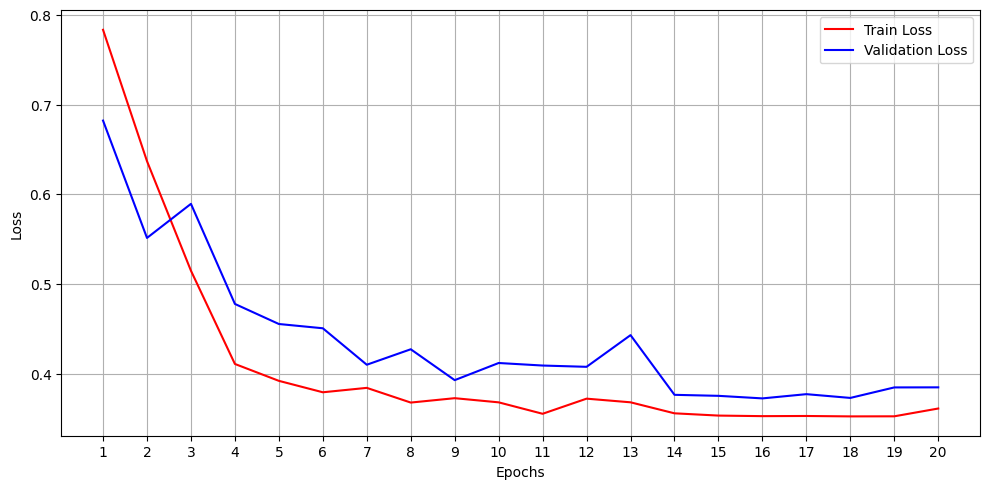

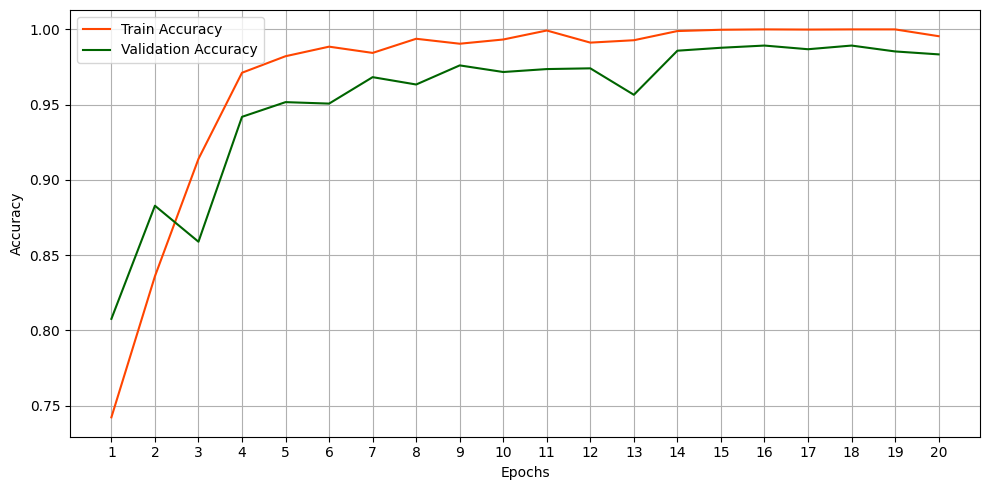

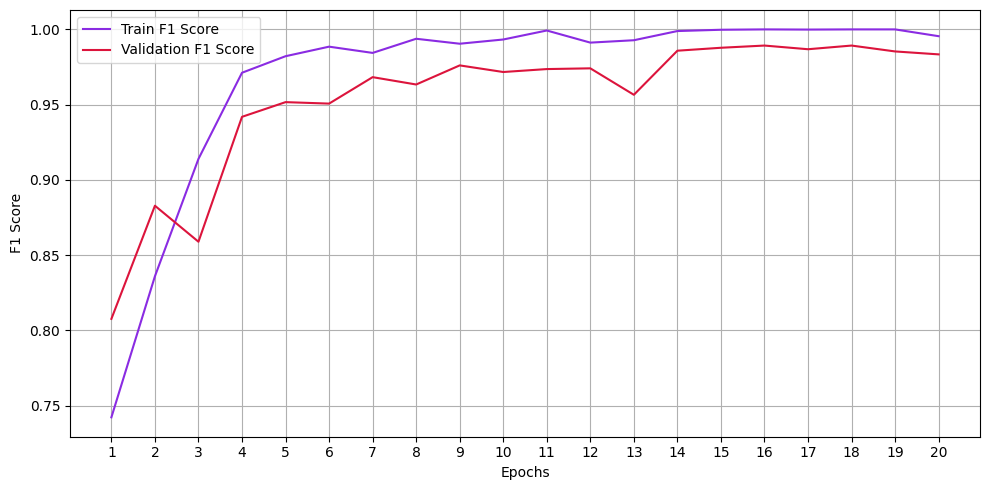

In [8]:
!pip install grad-cam==1.4.6

import matplotlib.pyplot as plt
import numpy as np

class PlotLearningCurves:
    
    def __init__(self, tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s):
        self.tr_losses = tr_losses
        self.val_losses = val_losses
        self.tr_accs = tr_accs
        self.val_accs = val_accs
        self.tr_f1s = tr_f1s
        self.val_f1s = val_f1s

    def plot(self, array_1, array_2, label_1, label_2, color_1, color_2):
        plt.plot(array_1, label=label_1, color=color_1)
        plt.plot(array_2, label=label_2, color=color_2)

    def create_figure(self):
        plt.figure(figsize=(10, 5))

    def decorate(self, ylabel, xlabel="Epochs"):
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xticks(ticks=np.arange(len(self.tr_accs)), labels=[i for i in range(1, len(self.tr_accs) + 1)])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def visualize(self):
        # Loss Plot
        self.create_figure()
        self.plot(self.tr_losses, self.val_losses, "Train Loss", "Validation Loss", "red", "blue")
        self.decorate(ylabel="Loss")

        # Accuracy Plot
        self.create_figure()
        self.plot(self.tr_accs, self.val_accs, "Train Accuracy", "Validation Accuracy", "orangered", "darkgreen")
        self.decorate(ylabel="Accuracy")

        # F1 Score Plot
        self.create_figure()
        self.plot(self.tr_f1s, self.val_f1s, "Train F1 Score", "Validation F1 Score", "blueviolet", "crimson")
        self.decorate(ylabel="F1 Score")

# Call this after training completes
PlotLearningCurves(
    tr_losses=trainer.tr_losses,
    val_losses=trainer.val_losses,
    tr_accs=trainer.tr_accs,
    val_accs=trainer.val_accs,
    tr_f1s=trainer.tr_f1s,
    val_f1s=trainer.val_f1s
).visualize()


In [9]:
!pip install huggingface_hub==0.23.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 13.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.5.0 requires fsspec[http]<=2024.12.0,>=2023.1.0, but you have fsspec 2025.3.2 which is incompatible.
datasets 3.5.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.23.0 which is incompatible.
transformers 4.51.1 requires huggingface-hub<1.0,>=0.30.0, but you have huggingface-hub 0.23.0 which is incompatible.
diffusers 0.32.2 requires huggingface-hub>=0.23.2, but you have huggingface-hub 0.23.0 which is incompatible.
peft 0.14.0 requires huggingface-hub>=0.25.0, but you have huggingface-hub 0.23.0 which is incompatible.


Forward shape (should be [2, 4]): torch.Size([2, 4])
Model loaded successfully
Dataset class mapping: {'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}

=== Test Accuracy === 1235/1279 = 96.56%

                      precision    recall  f1-score   support

     Mild Impairment      0.947     0.989     0.967       179
 Moderate Impairment      1.000     1.000     1.000        12
       No Impairment      0.982     0.961     0.972       640
Very Mild Impairment      0.949     0.962     0.956       448

            accuracy                          0.966      1279
           macro avg      0.970     0.978     0.974      1279
        weighted avg      0.966     0.966     0.966      1279



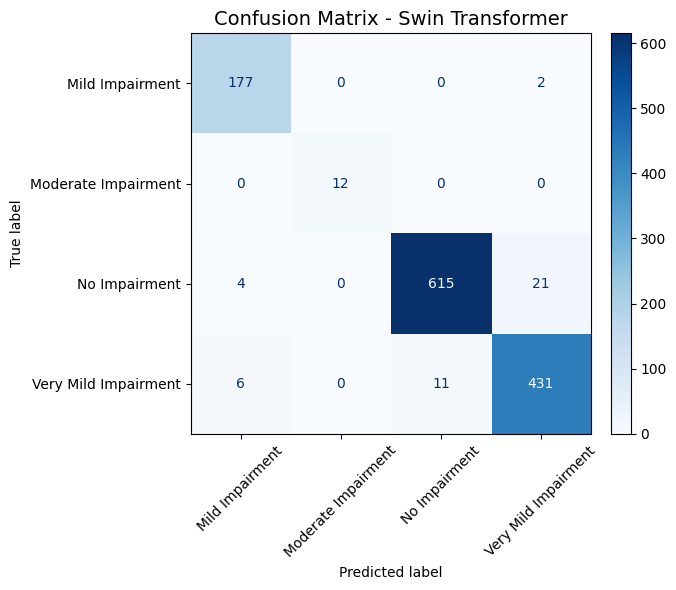


Grad-CAM target layer: LayerNorm((1024,), eps=1e-05, elementwise_affine=True)


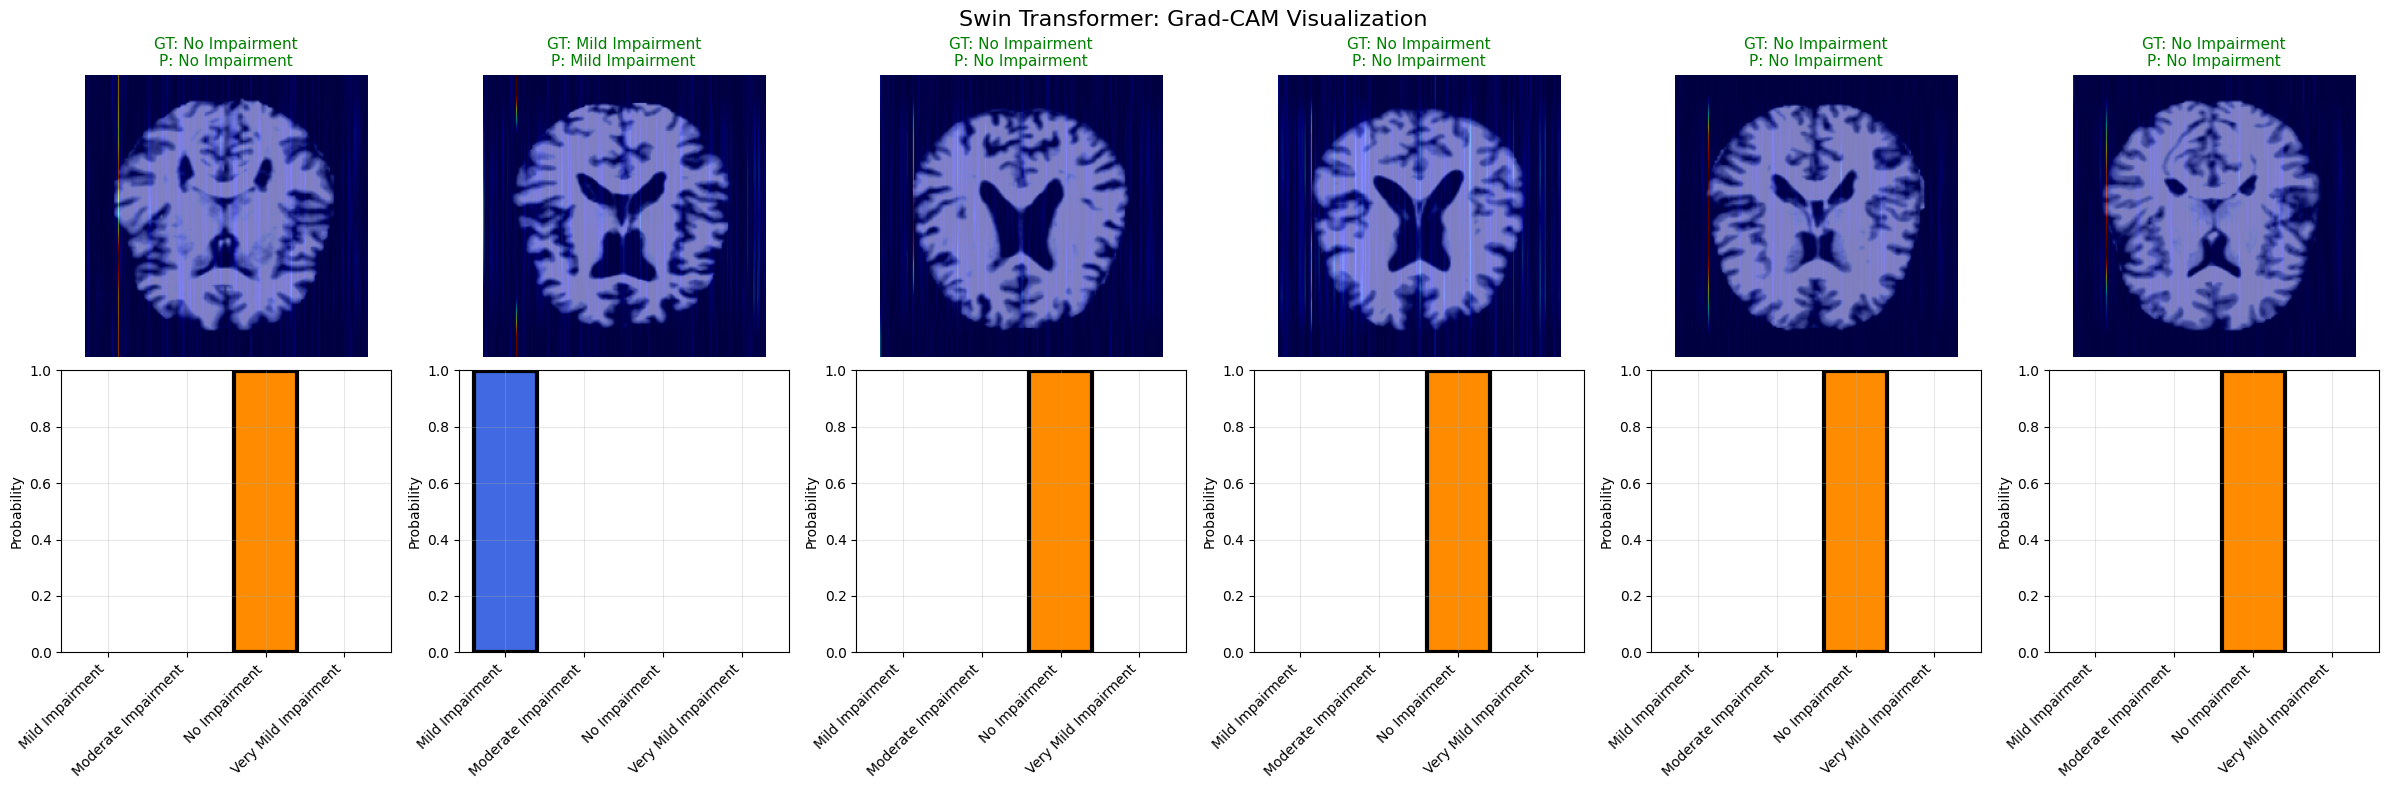

In [10]:
import os
import torch
import torch.nn as nn
import timm
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ==== Config ====
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir    = "/kaggle/working/saved_models"
save_prefix = "mri_swin_finetuned"
TEST_DIR    = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test"

classes     = {'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}
class_names = [k for k, v in sorted(classes.items(), key=lambda x: x[1])]

# ==== Model with overridden forward ====
class SwinHead(nn.Module):
    def __init__(self, in_features=1024, hidden=256, num_classes=4):
        super().__init__()
        self.norm = nn.LayerNorm(in_features)
        self.fc1  = nn.Linear(in_features, hidden)
        self.fc2  = nn.Linear(hidden, num_classes)

    def forward(self, x):
        x = self.norm(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

class SwinWithHead(nn.Module):
    def __init__(self):
        super().__init__()
        # Load backbone, strip everything after feature extraction
        self.backbone = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=False,
            num_classes=0,  # returns pooled (B, 1024)
            global_pool='avg'  # force global average pooling
        )
        self.head = SwinHead(in_features=1024, hidden=256, num_classes=4)

    def forward(self, x):
        x = self.backbone(x)   # (B, 1024)
        x = self.head(x)       # (B, 4)
        return x

# Build and verify shape before loading weights
model = SwinWithHead().to(device)
dummy = torch.randn(2, 3, 224, 224).to(device)
with torch.no_grad():
    out = model(dummy)
print("Forward shape (should be [2, 4]):", out.shape)

# Load weights — remap keys: saved has no prefix, model now has backbone.* prefix
state_dict = torch.load(
    os.path.join(save_dir, f"{save_prefix}_best_model.pth"),
    map_location=device,
    weights_only=True
)

# Remap: patch_embed.* -> backbone.patch_embed.*, head.* -> head.*
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith("head."):
        new_state_dict[k] = v          # head keys stay as-is
    else:
        new_state_dict[f"backbone.{k}"] = v  # backbone keys get prefix

model.load_state_dict(new_state_dict)
model.eval()
print("Model loaded successfully")

# ==== Test Dataloader ====
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
ts_dl        = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Dataset class mapping:", test_dataset.class_to_idx)

# ==== Inference ====
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in ts_dl:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

correct = np.sum(np.array(all_preds) == np.array(all_labels))
total   = len(all_labels)
print(f"\n=== Test Accuracy === {correct}/{total} = {100*correct/total:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

# ==== Confusion Matrix ====
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
fig.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Confusion Matrix - Swin Transformer", fontsize=14)
plt.tight_layout()
plt.show()

# ==== Grad-CAM ====
def get_swin_target_layer(model):
    for name, module in model.named_modules():
        if 'layers.3.blocks' in name and 'norm1' in name:
            return module
    return list(model.modules())[-3]

def swin_reshape_transform(tensor):
    if tensor.dim() == 3:
        B, HW, C = tensor.shape
        H = W = int(HW ** 0.5)
        return tensor.reshape(B, H, W, C).permute(0, 3, 1, 2)
    return tensor

target_layer = get_swin_target_layer(model)
print(f"\nGrad-CAM target layer: {target_layer}")

class_colors = {
    'No Impairment':        'darkorange',
    'Very Mild Impairment': 'seagreen',
    'Moderate Impairment':  'salmon',
    'Mild Impairment':      'royalblue'
}

try:
    cam = GradCAM(model=model, target_layers=[target_layer],
                  reshape_transform=swin_reshape_transform)

    sample_indices = random.sample(range(len(test_dataset)), 6)
    sample_images  = [test_dataset[i][0] for i in sample_indices]
    sample_labels  = [test_dataset[i][1] for i in sample_indices]
    input_tensor   = torch.stack(sample_images).to(device)
    true_labels    = torch.tensor(sample_labels).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        preds   = outputs.argmax(dim=1)

    targets  = [ClassifierOutputTarget(p.item()) for p in preds]
    cam_maps = cam(input_tensor, targets=targets)

    fig, axes = plt.subplots(2, 6, figsize=(24, 8))
    for i in range(6):
        img = input_tensor[i].cpu().permute(1, 2, 0).numpy()
        img = np.clip((img * 0.5) + 0.5, 0, 1)
        cam_map = cv2.resize(cam_maps[i], (img.shape[1], img.shape[0]))
        overlay = show_cam_on_image(img, cam_map, use_rgb=True)

        axes[0, i].imshow(overlay)
        axes[0, i].set_title(
            f"GT: {class_names[true_labels[i]]}\nP: {class_names[preds[i]]}",
            color="green" if preds[i] == true_labels[i] else "red", fontsize=11
        )
        axes[0, i].axis("off")

        probs    = torch.nn.functional.softmax(outputs[i].unsqueeze(0), dim=1)[0].cpu().numpy()
        pred_idx = preds[i].item()
        bars = axes[1, i].bar(range(len(class_names)), probs,
                              color=[class_colors.get(c, 'gray') for c in class_names])
        bars[pred_idx].set_edgecolor('black')
        bars[pred_idx].set_linewidth(3)
        axes[1, i].set_xticks(range(len(class_names)))
        axes[1, i].set_xticklabels(class_names, rotation=45, ha='right')
        axes[1, i].set_ylim(0, 1)
        axes[1, i].set_ylabel('Probability')
        axes[1, i].grid(True, alpha=0.3)

    plt.suptitle("Swin Transformer: Grad-CAM Visualization", fontsize=16)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Grad-CAM error: {e}")

In [11]:
# # ==== Gradio Interface ====
# test_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5] * 3, [0.5] * 3)
# ])

# def predict_with_gradcam(image_pil):
#     image_rgb = image_pil.convert("RGB")
#     input_tensor = test_transform(image_rgb).unsqueeze(0).to(device)

#     with torch.no_grad():
#         output = model(input_tensor)
#         pred_class = output.argmax(dim=1).item()
#         label = class_names[pred_class]

#     # Grad-CAM requires gradients
#     targets = [ClassifierOutputTarget(pred_class)]
#     cam_map = cam(input_tensor, targets=targets)[0]

#     image_np = np.array(image_rgb).astype(np.float32) / 255.0
#     cam_map_resized = cv2.resize(cam_map, (image_np.shape[1], image_np.shape[0]))
#     cam_overlay = show_cam_on_image(image_np, cam_map_resized, use_rgb=True)

#     return label, cam_overlay

# gr.Interface(
#     fn=predict_with_gradcam,
#     inputs=gr.Image(type="pil", label="Upload MRI Image"),
#     outputs=[gr.Label(label="Predicted Label"), gr.Image(label="Grad-CAM Heatmap")],
#     title="ViT MRI Classifier",
#     description="Upload an MRI to get predicted diagnosis and a Grad-CAM heatmap."
# ).launch()